# ED 2022 Dataset - Normal Vital Signs Analysis by Age Group

Analyzes `ed2022-stata.csv` (NHAMCS Emergency Department data) with focus on patients whose vital signs fall within **normal ranges** for their age group (AGER).

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency

DATA_PATH = Path("ed2022-stata.csv")
sns.set_theme(style="whitegrid", palette="husl")
%matplotlib inline

In [25]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

Loaded 16,025 rows, 913 columns


## 1. Extracted Table: Normal Vital Sign Ranges by Age Group (AGER)

Reference table defining normal ranges for each vital sign by age group. Values within these ranges (inclusive) are considered normal.

In [26]:
# Normal vital sign ranges by AGER (from reference table)
# AGER: 1=Under 15, 2=15-24, 3=25-44, 4=45-64, 5=65-74, 6=75+

normal_ranges = pd.DataFrame({
    "AGER": [1, 2, 3, 4, 5, 6],
    "Age Group": [
        "Under 15 years",
        "15-24 years",
        "25-44 years",
        "45-64 years",
        "65-74 years",
        "75 years and over",
    ],
    "TEMPF (code)": ["975-995", "975-995", "975-995", "970-995", "968-993", "965-990"],
    "PULSE": ["70-110", "60-100", "60-100", "60-100", "60-100", "60-100"],
    "RESPR": ["18-30", "12-20", "12-20", "12-20", "12-20", "12-22"],
    "BPSYS": ["90-120", "100-120", "100-125", "110-130", "110-140", "110-145"],
    "BPDIAS": ["50-80", "60-80", "60-85", "65-85", "65-90", "65-90"],
    "POPCT": ["95-100", "95-100", "95-100", "95-100", "94-100", "93-100"],
})

display(normal_ranges)

,AGER,Age Group,TEMPF (code),PULSE,RESPR,BPSYS,BPDIAS,POPCT
0,1,Under 15 years,975-995,70-110,18-30,90-120,50-80,95-100
1,2,15-24 years,975-995,60-100,12-20,100-120,60-80,95-100
2,3,25-44 years,975-995,60-100,12-20,100-125,60-85,95-100
3,4,45-64 years,970-995,60-100,12-20,110-130,65-85,95-100
4,5,65-74 years,968-993,60-100,12-20,110-140,65-90,94-100
5,6,75 years and over,965-990,60-100,12-22,110-145,65-90,93-100


In [27]:
# Structured ranges for programmatic use (min, max)
ranges_dict = {
    1: {"TEMPF": (975, 995), "PULSE": (70, 110), "RESPR": (18, 30), "BPSYS": (90, 120), "BPDIAS": (50, 80), "POPCT": (95, 100)},
    2: {"TEMPF": (975, 995), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (100, 120), "BPDIAS": (60, 80), "POPCT": (95, 100)},
    3: {"TEMPF": (975, 995), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (100, 125), "BPDIAS": (60, 85), "POPCT": (95, 100)},
    4: {"TEMPF": (970, 995), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (110, 130), "BPDIAS": (65, 85), "POPCT": (95, 100)},
    5: {"TEMPF": (968, 993), "PULSE": (60, 100), "RESPR": (12, 20), "BPSYS": (110, 140), "BPDIAS": (65, 90), "POPCT": (94, 100)},
    6: {"TEMPF": (965, 990), "PULSE": (60, 100), "RESPR": (12, 22), "BPSYS": (110, 145), "BPDIAS": (65, 90), "POPCT": (93, 100)},
}

## 2. Identify Patients with Normal Vital Signs

For each record, we check if all available vital signs fall within the normal range for that patient's AGER. Missing values (-7, -8, -9) are excluded from the check.

In [28]:
def is_valid_vital(val):
    """Exclude missing/special codes: -7, -8, -9"""
    if pd.isna(val):
        return False
    try:
        v = float(val)
        return v > 0 and v not in (-7, -8, -9)
    except (TypeError, ValueError):
        return False


def is_normal_for_ager(row, ranges_dict):
    ager = row["AGER"]
    if pd.isna(ager) or ager not in ranges_dict:
        return np.nan
    r = ranges_dict[int(ager)]
    vital_cols = ["TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT"]
    for col in vital_cols:
        val = row.get(col)
        if not is_valid_vital(val):
            continue
        lo, hi = r[col]
        if not (lo <= float(val) <= hi):
            return False
    return True


# Apply: at least one valid vital must be present and all valid vitals must be normal
def all_vitals_normal(row, ranges_dict):
    ager = row["AGER"]
    if pd.isna(ager) or ager not in ranges_dict:
        return np.nan
    r = ranges_dict[int(ager)]
    vital_cols = ["TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT"]
    has_any = False
    for col in vital_cols:
        val = row.get(col)
        if not is_valid_vital(val):
            continue
        has_any = True
        lo, hi = r[col]
        if not (lo <= float(val) <= hi):
            return False
    return True if has_any else np.nan


df["all_normal"] = df.apply(lambda r: all_vitals_normal(r, ranges_dict), axis=1)

## 3. Summary by Age Group

In [29]:
# Filter to valid AGER (1-6), exclude IMMEDR 3/4/5, and exclude ADMIT=2
valid_ager = df[
    df["AGER"].isin([1, 2, 3, 4, 5, 6])
    & ~df["IMMEDR"].isin([3, 4, 5])
    & (df["ADMIT"] != 2)
].copy()

summary = valid_ager.groupby("AGER").agg(
    total=("AGER", "count"),
    all_normal_count=("all_normal", lambda x: (x == True).sum()),
    all_normal_pct=("all_normal", lambda x: 100 * (x == True).sum() / len(x) if len(x) > 0 else 0),
).reset_index()

summary["Age Group"] = summary["AGER"].map(
    {
        1: "Under 15 years",
        2: "15-24 years",
        3: "25-44 years",
        4: "45-64 years",
        5: "65-74 years",
        6: "75 years and over",
    }
)

summary = summary[["AGER", "Age Group", "total", "all_normal_count", "all_normal_pct"]]
summary.columns = ["AGER", "Age Group", "Total Visits", "Normal Vitals Count", "% Normal Vitals"]

display(summary)

,AGER,Age Group,Total Visits,Normal Vitals Count,% Normal Vitals
0,1,Under 15 years,1315,280,21.292776
1,2,15-24 years,953,168,17.628541
2,3,25-44 years,1864,333,17.864807
3,4,45-64 years,1727,211,12.217719
4,5,65-74 years,808,123,15.222772
5,6,75 years and over,835,131,15.688623


In [30]:
# Subset: only patients with ALL vitals normal
normal_df = valid_ager[valid_ager["all_normal"] == True].copy()
print(f"Total records with valid AGER: {len(valid_ager):,}")
print(f"Records with all vitals normal: {len(normal_df):,}")

Total records with valid AGER: 7,502
Records with all vitals normal: 1,246


## 4. Vital Sign Statistics (Normal vs All) by Age Group

In [31]:
vital_cols = ["TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT"]

def to_numeric_ignore_missing(s):
    s = pd.to_numeric(s, errors="coerce")
    return s[(s > 0) & (~s.isin([-7, -8, -9]))]

stats_list = []
for ager in range(1, 7):
    sub_all = valid_ager[valid_ager["AGER"] == ager]
    sub_normal = normal_df[normal_df["AGER"] == ager]
    age_label = summary[summary["AGER"] == ager]["Age Group"].iloc[0]
    for col in vital_cols:
        vals_all = to_numeric_ignore_missing(sub_all[col])
        vals_norm = to_numeric_ignore_missing(sub_normal[col])
        stats_list.append({
            "AGER": ager,
            "Age Group": age_label,
            "Vital": col,
            "Group": "All",
            "N": len(vals_all),
            "Mean": vals_all.mean(),
            "Std": vals_all.std(),
        })
        stats_list.append({
            "AGER": ager,
            "Age Group": age_label,
            "Vital": col,
            "Group": "Normal only",
            "N": len(vals_norm),
            "Mean": vals_norm.mean(),
            "Std": vals_norm.std(),
        })

stats_df = pd.DataFrame(stats_list)
display(stats_df.head(24))

,AGER,Age Group,Vital,Group,N,Mean,Std
0,1,Under 15 years,TEMPF,All,1205,988.885477,14.857132
1,1,Under 15 years,TEMPF,Normal only,273,983.175824,4.705894
2,1,Under 15 years,PULSE,All,1158,118.878238,39.490706
3,1,Under 15 years,PULSE,Normal only,248,93.068548,10.310922
4,1,Under 15 years,RESPR,All,1181,26.261643,10.040686
5,1,Under 15 years,RESPR,Normal only,264,21.719697,3.161831
6,1,Under 15 years,BPSYS,All,818,110.902200,14.330774
7,1,Under 15 years,BPSYS,Normal only,207,106.072464,7.434475
8,1,Under 15 years,BPDIAS,All,817,68.443084,11.754515
9,1,Under 15 years,BPDIAS,Normal only,207,66.077295,6.965506


## 5. Visualization: % with Normal Vitals by Age Group

/var/folders/gs/88s910y57tjb5dx_52h8hbgc0000gn/T/ipykernel_25018/2605838712.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary["Age Group"], rotation=30, ha="right")


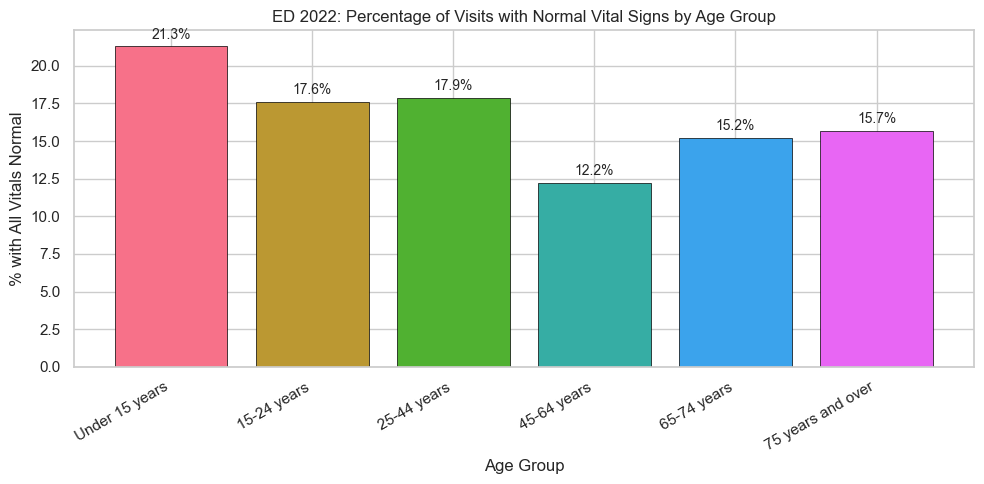

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    summary["Age Group"],
    summary["% Normal Vitals"],
    color=sns.color_palette("husl", 6),
    edgecolor="black",
    linewidth=0.5,
)
ax.set_ylabel("% with All Vitals Normal")
ax.set_xlabel("Age Group")
ax.set_title("ED 2022: Percentage of Visits with Normal Vital Signs by Age Group")
ax.set_xticklabels(summary["Age Group"], rotation=30, ha="right")
for b, pct in zip(bars, summary["% Normal Vitals"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5, f"{pct:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Count of Normal vs Non-Normal by Age Group

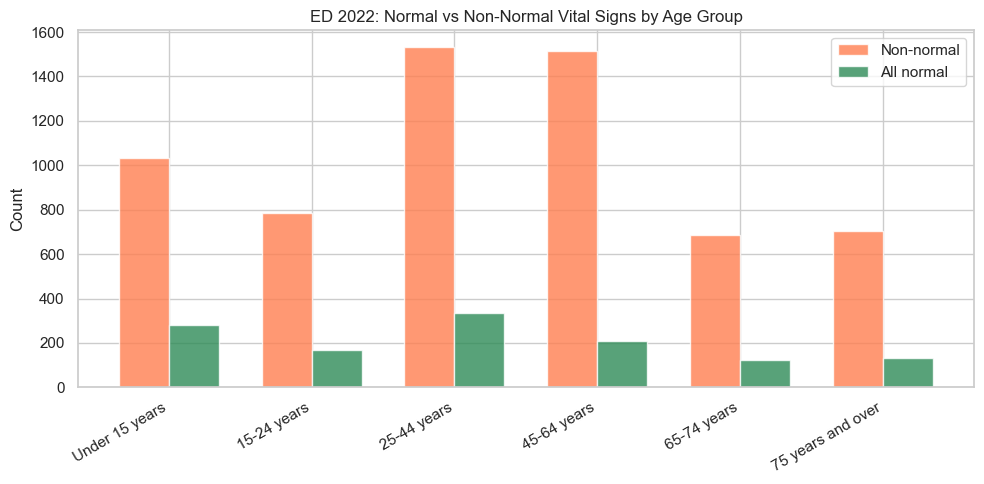

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w / 2, summary["Total Visits"] - summary["Normal Vitals Count"], w, label="Non-normal", color="coral", alpha=0.8)
ax.bar(x + w / 2, summary["Normal Vitals Count"], w, label="All normal", color="seagreen", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(summary["Age Group"], rotation=30, ha="right")
ax.set_ylabel("Count")
ax.set_title("ED 2022: Normal vs Non-Normal Vital Signs by Age Group")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Correlation & Association Analysis: Predictors of ADMIT == 2

Analyzes **correlation** (numeric) and **association** (categorical) of each column with the outcome `ADMIT == 2` (admitted to hospital). Includes logistic regression for predictive strength.

**Note:** Correlation/association ≠ causation. Observational data cannot establish causality; these results show statistical associations only.

In [ ]:
# Outcome: ADMIT == 2 (hospital admission)
df["ADMIT_2"] = (pd.to_numeric(df["ADMIT"], errors="coerce") == 2).astype(int)
df_admit = df.copy()  # working copy for analysis
print(f"ADMIT == 2: {df['ADMIT_2'].sum():,} / {len(df):,} ({100*df['ADMIT_2'].mean():.1f}%)")

# Exclude non-analyzable columns (IDs, codes, free text)
exclude = ["ADMIT", "ADMIT_2", "HOSPCODE", "PATCODE", "CSTRATM", "CPSUM", "PATWT", "EDWT", "BOARDED"]
exclude += [c for c in df.columns if any(x in c for x in ["DRUGID", "PRESCR", "RX", "DIAG", "CAUSE", "RFV", "HDDIAG", "GPMED", "MED"])]
exclude += [c for c in df.columns if "COMSTAT" in c or "CONTSUB" in c]

# Key numeric columns (first 200 cols, excluding above)
numeric_candidates = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_candidates if c not in exclude and c in df.columns[:250]]
for c in ["TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT", "TOTCHRON", "TOTDIAG", "TOTPROC", "LOS", "NUMGIV", "NUMMED"]:
    if c in df.columns and c not in numeric_cols and c not in exclude:
        numeric_cols.append(c)

# Key categorical (low cardinality)
cat_candidates = ["AGER", "SEX", "RESIDNCE", "RACER", "PAYTYPER", "IMMEDR", "INJURY", "ARREMS", "NOPAY", "PAYPRIV", "PAYMCARE", "PAYMCAID", "SEEN72", "EPISODE", "ADMTPHYS"]
cat_cols = [c for c in cat_candidates if c in df.columns and c not in exclude]

print(f"Numeric columns: {len(numeric_cols)}, Categorical: {len(cat_cols)}")

# 1. Numeric: Point-biserial correlation (Pearson with binary outcome)
corr_list = []
for col in numeric_cols:
    x = pd.to_numeric(df_admit[col], errors="coerce")
    y = df_admit["ADMIT_2"]
    mask = x.notna() & y.notna() & ~x.isin([-9, -8, -7])
    if mask.sum() < 100:
        continue
    r, p = stats.pearsonr(x[mask], y[mask])
    corr_list.append({"Column": col, "Correlation": r, "p-value": p})
corr_df = pd.DataFrame(corr_list).sort_values("Correlation", key=abs, ascending=False)
corr_numeric = corr_df.set_index("Column")["Correlation"]  # Series for downstream use
print("\nTop 25 numeric columns by |correlation| with ADMIT=2:")
display(corr_df.head(25))

ADMIT == 2: 81 / 16,025 (0.5%)
Numeric columns: 160, Categorical: 14

Top 25 numeric columns by |correlation| with ADMIT=2:


/var/folders/gs/88s910y57tjb5dx_52h8hbgc0000gn/T/ipykernel_25018/1027486037.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x[mask], y[mask])


,Column,Correlation,p-value
154,ADMITHOS,0.182492,4.902120e-120
145,RETREFFU,-0.099065,3.063908e-36
112,CENTLINE,0.073021,2.135323e-20
54,ESRD,0.066654,3.002003e-17
123,TOTPROC,0.065063,4.326102e-16
128,PULSED,0.064413,6.795024e-08
86,EKG,0.062603,2.154629e-15
124,NUMGIV,0.061743,5.163716e-15
109,BPAP,0.061397,7.310230e-15
64,TOTCHRON,0.061373,1.231264e-14


In [35]:
# 2. Categorical columns: Cramér's V (association with ADMIT_2)
def cramers_v(x, y):
    """Cramér's V for categorical-categorical association. 0=no association, 1=perfect."""
    from scipy.stats import chi2_contingency
    conf = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(conf)
    n = conf.sum().sum()
    min_dim = min(conf.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cat_assoc = []
for col in cat_cols:
    try:
        # Drop rows with missing/invalid
        mask = df_admit[col].notna() & ~df_admit[col].isin([-9, -8, -7, -7.0, -8.0, -9.0])
        if mask.sum() < 100:
            continue
        v = cramers_v(df_admit.loc[mask, col].astype(str), df_admit.loc[mask, "ADMIT_2"])
        cat_assoc.append({"Column": col, "Cramér's V": v, "Type": "Categorical"})
    except Exception:
        pass

cat_assoc_df = pd.DataFrame(cat_assoc).sort_values("Cramér's V", ascending=False)
print("Top 25 categorical columns by Cramér's V (association with ADMIT=2):")
display(cat_assoc_df.head(25))

Top 25 categorical columns by Cramér's V (association with ADMIT=2):


,Column,Cramér's V,Type
0,AGER,0.066285,Categorical
6,ARREMS,0.060035,Categorical
4,PAYTYPER,0.057536,Categorical
9,PAYMCARE,0.044953,Categorical
2,RESIDNCE,0.033613,Categorical
10,PAYMCAID,0.017076,Categorical
12,EPISODE,0.011025,Categorical
1,SEX,0.008307,Categorical
8,PAYPRIV,0.007828,Categorical
3,RACER,0.005140,Categorical


In [36]:
# Logistic regression: predictive strength (association ≠ causation)
# Uses top predictors to model P(ADMIT==2)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Build model matrix from top numeric predictors
model_cols = [c for c in corr_numeric.index[:20] if c in df.columns]
X = df[model_cols].copy()
for c in model_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X)
X_imp = pd.DataFrame(X_imp, columns=model_cols, index=df.index)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
y = df["ADMIT_2"]
mask = ~np.isnan(X_scaled).any(axis=1) & y.notna()
X_fit, y_fit = X_scaled[mask], y[mask].values

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_fit, y_fit)
coef_df = pd.DataFrame({"Column": model_cols, "Coefficient": model.coef_[0]})
coef_df["Abs_Coef"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values("Abs_Coef", ascending=False)
print("Logistic regression coefficients (top predictors of ADMIT==2):")
display(coef_df.head(20))

Logistic regression coefficients (top predictors of ADMIT==2):


,Column,Coefficient,Abs_Coef
0,ADMITHOS,2.063558,2.063558
4,TOTPROC,0.518969,0.518969
1,RETREFFU,-0.279865,0.279865
9,TOTCHRON,-0.270369,0.270369
17,CONSULT,-0.231235,0.231235
10,ARREMS,0.198428,0.198428
14,AGER,0.169560,0.169560
5,PULSED,0.164547,0.164547
11,COPD,0.163872,0.163872
13,IVFLUIDS,-0.138208,0.138208


### Top Correlations & Associations with ADMIT == 2 (Visualization)

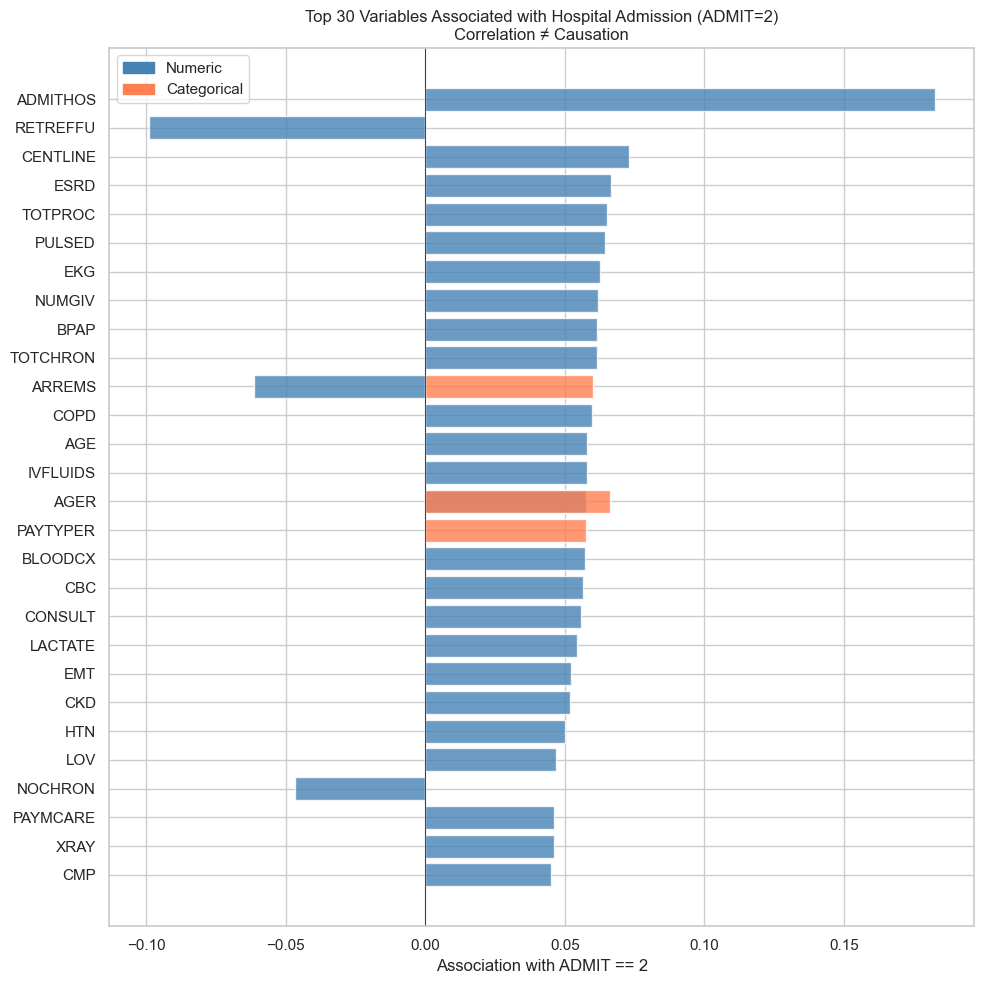

In [37]:
# Combine numeric and categorical associations
_corr_series = corr_numeric["Correlation"] if isinstance(corr_numeric, pd.DataFrame) else corr_numeric
all_assoc = pd.concat([
    _corr_series.rename("Association").to_frame().assign(Type="Numeric (Point-biserial)"),
    cat_assoc_df.set_index("Column")["Cramér's V"].rename("Association").to_frame().assign(Type="Categorical (Cramér's V)"),
])
all_assoc = all_assoc.sort_values("Association", key=abs, ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["steelblue" if t == "Numeric (Point-biserial)" else "coral" for t in all_assoc["Type"]]
ax.barh(all_assoc.index.astype(str)[::-1], all_assoc["Association"][::-1], color=colors[::-1], alpha=0.8)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Association with ADMIT == 2")
ax.set_title("Top 30 Variables Associated with Hospital Admission (ADMIT=2)\nCorrelation ≠ Causation")
ax.legend(handles=[
    plt.matplotlib.patches.Patch(color="steelblue", label="Numeric"),
    plt.matplotlib.patches.Patch(color="coral", label="Categorical"),
])
plt.tight_layout()
plt.show()